In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [3]:
data.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
attrition_count = data['Attrition'].value_counts()
attrition_rate = (data['Attrition'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %'
print("Rincian Karyawan Resign vs Bertahan:\n", attrition_count)
print("Persentase Karyawan Resign vs Bertahan:\n", attrition_rate)

Rincian Karyawan Resign vs Bertahan:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64
Persentase Karyawan Resign vs Bertahan:
 Attrition
No     83.88 %
Yes    16.12 %
Name: proportion, dtype: str


Data Attrition menunjukan nilai yang sudah memasuki kategori dengan tingkat turnover tinggi yaitu diatas 15%. Riset Gallup dalam reportnya via Evalflow HR Benchmarks 2026 secara konsisten menetapkan bahwa tingkat turnover tahunan di bawah 10% secara umum dianggap "sehat" untuk sebagian besar industri. Mekari Talenta, salah satu penyedia sistem HRIS terbesar di Indonesia, merilis pemetaan turnover yang menetapkan rentang 5% – 10% sebagai Low turnover (stabilitas tinggi), dan 10% – 15% sebagai healthy and balanced turnover.

In [6]:
# 1. Ambil nama kolom yang tipe datanya teks/kategori
kolom_kategorikal = data.select_dtypes(include=['object', 'str']).columns

# 2. Hapus 'Attrition' dari daftar looping (karena ini adalah target kita)
# Jika tidak dihapus, nanti ada tabel Attrition vs Attrition (isinya 100% Yes, 100% No)
if 'Attrition' in kolom_kategorikal:
    kolom_kategorikal = kolom_kategorikal.drop('Attrition')

# 3. Lakukan perulangan (looping)
for kolom in kolom_kategorikal:
    print(f"=== Persentase Attrition Berdasarkan: {kolom} (%) ===")
    
    # Gunakan crosstab dengan normalize='index' seperti yang kita pelajari sebelumnya
    tabel_pct = pd.crosstab(data[kolom], data['Attrition'], normalize='index') * 100
    
    # Tampilkan dengan pembulatan 2 angka di belakang koma
    print(tabel_pct.round(2))
    
    print("-" * 50, "\n") # Garis pembatas agar rapi di layar

=== Persentase Attrition Berdasarkan: BusinessTravel (%) ===
Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96
-------------------------------------------------- 

=== Persentase Attrition Berdasarkan: Department (%) ===
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63
-------------------------------------------------- 

=== Persentase Attrition Berdasarkan: EducationField (%) ===
Attrition            No    Yes
EducationField                
Human Resources   74.07  25.93
Life Sciences     85.31  14.69
Marketing         77.99  22.01
Medical           86.42  13.58
Other             86.59  13.41
Technical Degree  75.76  24.24
-------------------------------------------------- 

=== Persentase Attrition Berdasarkan: Gender (%) ===
Attrition     No

Data attrition rate yang digolongkan berdasarkan kolom-kolom data kategorikal yang ada menunjukan beberapa golongan yang memiliki attrition rate tinggi yaitu :
- Karyawan dengan perjalanan bisnis yang rutin (Travel_Frequently 24.91)
- Karyawan dengan Departmen Human Resources 19.05 & Sales 20.63
- Karyawan dengan Jobrole Human Resources 23.08, Laboratory Technician 23.94, Research Scientist 16.10, Sales Executive 17.48, dan Sales Representative 39.76
- Karyawan dengan latar belakang pendidikan Human Resources 25.93, Marketing 22.01, Technical Degree 24.24
- Karyawan dengan MaritalStatusnya adalah Single 25.53
- Karyawan dengan wajib atau sering Lembur 30.53

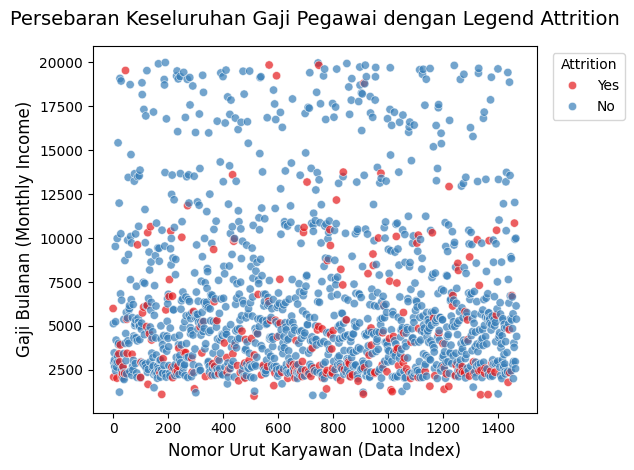

In [11]:
# Membuat scatterplot tradisional
# Sumbu X diisi dengan index data (nomor urut baris), sumbu Y diisi gaji
sns.scatterplot(data=data, x=data.index, y='MonthlyIncome', hue='Attrition', alpha=0.7, palette='Set1')
plt.title('Persebaran Keseluruhan Gaji Pegawai dengan Legend Attrition', fontsize=14, pad=15)
plt.xlabel('Nomor Urut Karyawan (Data Index)', fontsize=12)
plt.ylabel('Gaji Bulanan (Monthly Income)', fontsize=12)
# Menata posisi legend (keterangan warna)
plt.legend(title='Attrition', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Karyawan yang Berhenti paling banyak berada pada persebaran data monthly income dibawah 5000. Hal ini mengindikasikan bahwa perusahaan memiliki kebijakan upah dan beban kerja yang kurang layak yang memicu turnover tinggi. Oleh karena itu kita akan memulai meneliti monthlyincome berdasarkan job role agar lebih tersegmentasi karena masing-masing job role memiliki permasalahan, kinerja dan jumlah yang berbeda

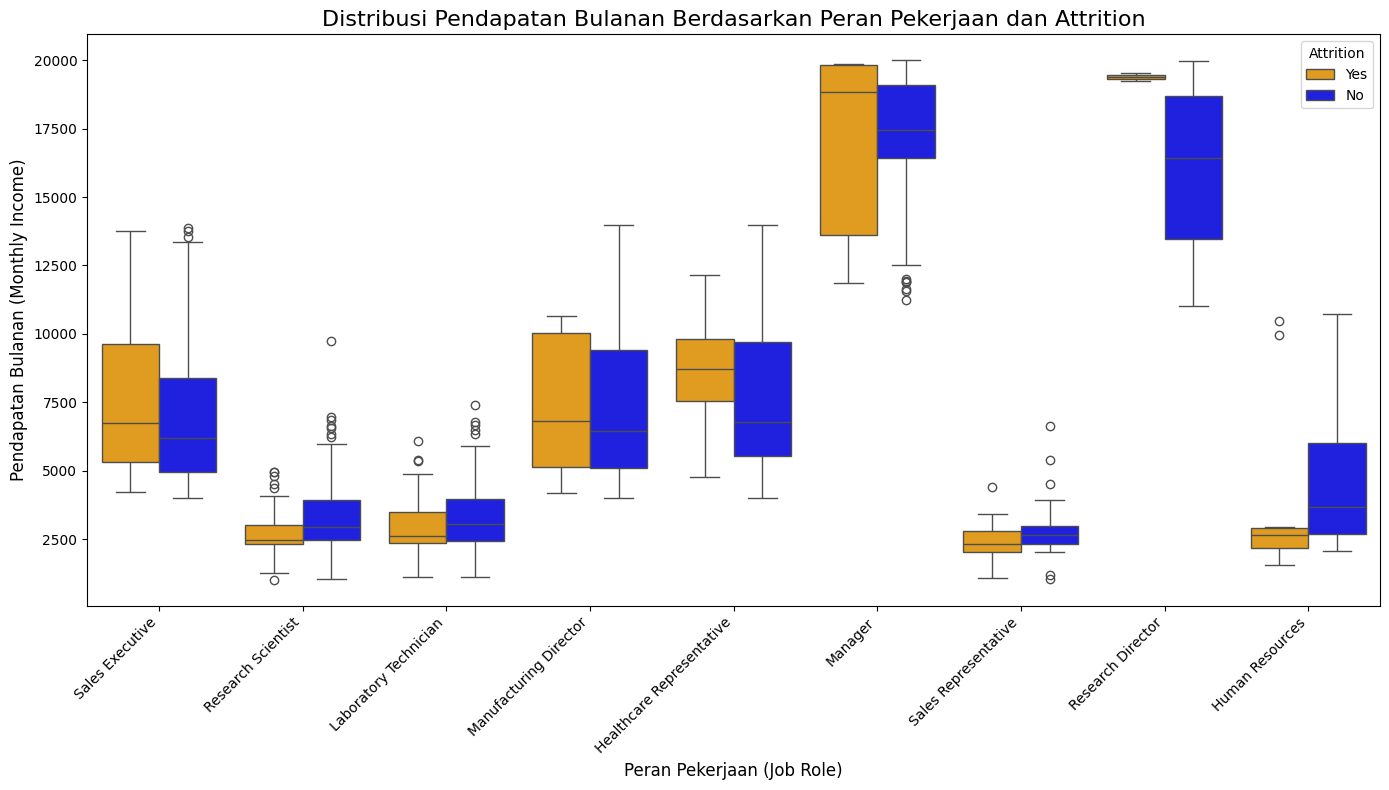

In [31]:
# Distribusi Pendapatan Bulanan Berdasarkan Peran Pekerjaan dan Attrition
# Mengatur ukuran figur agar lebih mudah dibaca, terutama karena kategori JobRole cukup banyak
plt.figure(figsize=(14, 8))
# Membuat Boxplot dengan Seaborn
sns.boxplot(
    data=data, 
    x='JobRole', 
    y='MonthlyIncome', 
    hue='Attrition',
    palette={'No': 'blue', 'Yes': 'orange'} # Menentukan warna secara spesifik
)
# Menambahkan judul dan label sumbu
plt.title('Distribusi Pendapatan Bulanan Berdasarkan Peran Pekerjaan dan Attrition', fontsize=16)
plt.xlabel('Peran Pekerjaan (Job Role)', fontsize=12)
plt.ylabel('Pendapatan Bulanan (Monthly Income)', fontsize=12)
# Memutar label sumbu X agar tidak saling tumpang tindih
plt.xticks(rotation=45, ha='right')
# Merapikan tata letak agar tidak terpotong
plt.tight_layout()
# Menampilkan plot
plt.show()

ada 2 insight penting yang didapat :
- beberapa role menunjukan yang attrition 'no' memiliki median gaji lebih besar dibandingkan yang 'yes' yaitu : Human Resources, Laboratory Technician, Research Scientist, dan Sales Representative. ini menunjukan bukti bahwa alasan kuat mereka keluar dari perusahaan adalah gaji.
- beberapa role menunjukan yang attrition 'yes' memiliki median gaji lebih besar dibandingkan yang 'no' yaitu : 'Sales Executive', 'Manufacturing Director', 'Healthcare Representative', 'Manager','Research DIrector'. ini menunjukan tanda bahwa gaji bukan alasan utama mereka dalam resign. (setidaknya kebijakan gaji untuk beberapa role tersebut bukan suatu kesalahan atau yang harus diperbaiki secara mendesak)

berdasarkan data Glassdoor & PayScale (Laporan Historis 2015-2017) :
- Research Scientist di pasar kerja memilki gaji sekitar $5.800 – $8.300 per bulan sedangkan di perusaan hanya $3.200 per bulan
- Laboratory Technician di pasar kerja memilki gaji sekitar $3.300 – $4.100 per bulan sedangkan di perusaan hanya sekitar $3.200 per bulan
- Human Resources di pasar kerja memilki gaji sekitar $4.100 – $5.400 per bulan sedangkan di perusaan hanya sekitar $2.900 per bulan
- Sales Representative di pasar kerja memilki gaji sekitar sekitar $3.750 – $5.000 per bulan sedangkan di perusaan hanya sekitar $2.600 per bulan

data ini menguatkan bahwa beberapa role yg alasan resign nya adalah gaji memiliki gaji yg kurang sesuai dengan pasar

1. Investigasi Lanjutan untuk Group 1 (The "Underpaid" Juniors)
Fokus: Laboratory Technician, Research Scientist, Sales Representative, HR
Kita tahu mereka keluar karena gaji kecil. Tapi apa pemicu (trigger) yang bikin mereka akhirnya nekat resign?

- Hipotesa 2A (Underpaid & Overworked): Cek silang MonthlyIncome mereka dengan OverTime. Apakah yang resign ini sudah gajinya di bawah median, tapi dipaksa lembur terus? (Gunakan bar chart: % Attrition berdasarkan OverTime khusus untuk 4 role ini).

- Hipotesa 2B (Harapan Palsu): Cek PercentSalaryHike (kenaikan gaji terakhir). Jangan-jangan gaji mereka kecil, dan kenaikan gaji terakhir mereka juga sangat miris (misal di bawah 13%).

- Hipotesa 2C (Faktor Bebas Tanggungan): Lu tadi nemu data Single punya attrition 25.53%. Coba cek, apakah mayoritas karyawan di Group 2 ini statusnya Single? Karyawan bergaji kecil + Single = Tidak ada rasa takut untuk resign kapan saja.

2. Investigasi Lanjutan untuk Group 2 (The "Stressed/Stagnant" Seniors)
Fokus: Sales Executive (karena memiliki jumlah attrition tinggi)
Kalau bukan karena gaji (karena gaji mereka yang keluar malah lebih tinggi), lalu karena apa?

- Hipotesa 1A (Travel Fatigue): Lu nemu data Travel_Frequently attrition-nya 24.91%. Coba cek silang BusinessTravel dengan JobRole di Group 1 (terutama Sales Exec). Apakah mereka yang gajinya besar ini burnout karena terlalu sering jalan dinas?

- Hipotesa 1B (Toxic Manager/Environment): Cek YearsWithCurrManager atau EnvironmentSatisfaction. Orang bergaji besar biasanya resign karena muak dengan bosnya atau budaya kerja yang toxic.

- Hipotesa 1C (Karir Mentok): Cek YearsSinceLastPromotion. Orang di posisi ini mungkin merasa karirnya mandek dan butuh tantangan baru di luar.

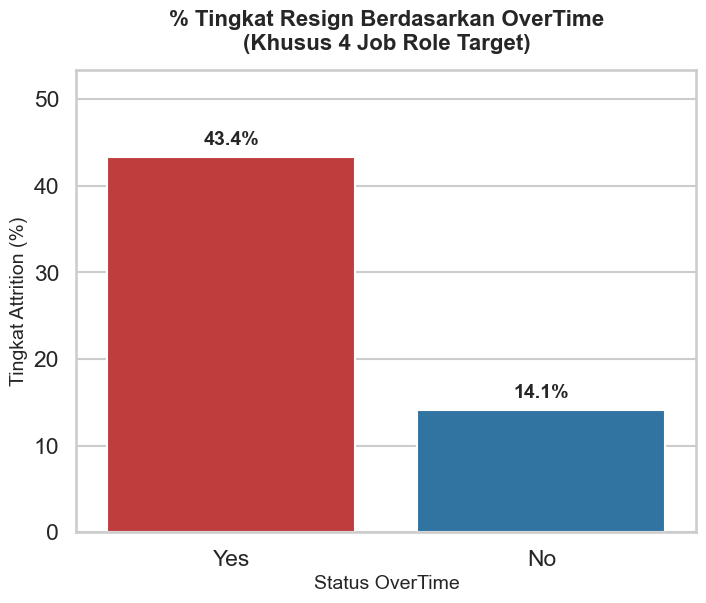

In [44]:
# % Tingkat Resign Berdasarkan OverTime Khusus 4 Job Role Target
# 1. Filter dataset HANYA untuk 4 profesi yang ditargetkan
target_roles = ['Laboratory Technician', 'Research Scientist', 'Sales Representative', 'Human Resources']
df_filtered = data[data['JobRole'].isin(target_roles)]

# 2. Menghitung persentase Attrition dari data yang sudah disaring
# normalize='index' akan menghitung proporsi per baris (per kategori OverTime)
attrition_pct = pd.crosstab(df_filtered['OverTime'], df_filtered['Attrition'], normalize='index')['Yes'] * 100

# Mengubahnya menjadi dataframe agar mudah di-plot oleh Seaborn
attrition_pct = attrition_pct.reset_index()
attrition_pct.rename(columns={'Yes': 'Attrition_Rate_Pct'}, inplace=True)

# 3. Membuat Visualisasi Bar Chart
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", context="talk")

ax = sns.barplot(
    data=attrition_pct, 
    x='OverTime', 
    y='Attrition_Rate_Pct',
    hue='OverTime',             # Ditambahkan untuk menghilangkan warning
    palette={'Yes': '#d62728', 'No': '#1f77b4'},
    order=['Yes', 'No'], 
    legend=False                # Mematikan legend agar tidak dobel dengan sumbu X
)

# 4. Merapikan judul dan sumbu
plt.title('% Tingkat Resign Berdasarkan OverTime\n(Khusus 4 Job Role Target)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Status OverTime', fontsize=14)
plt.ylabel('Tingkat Attrition (%)', fontsize=14)

# Memberi ruang ekstra di atas bar agar angka tidak terpotong
plt.ylim(0, attrition_pct['Attrition_Rate_Pct'].max() + 10) 

# 5. Menambahkan teks persentase di atas setiap bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 6), 
                textcoords='offset points',
                fontsize=14, fontweight='bold')

plt.show()


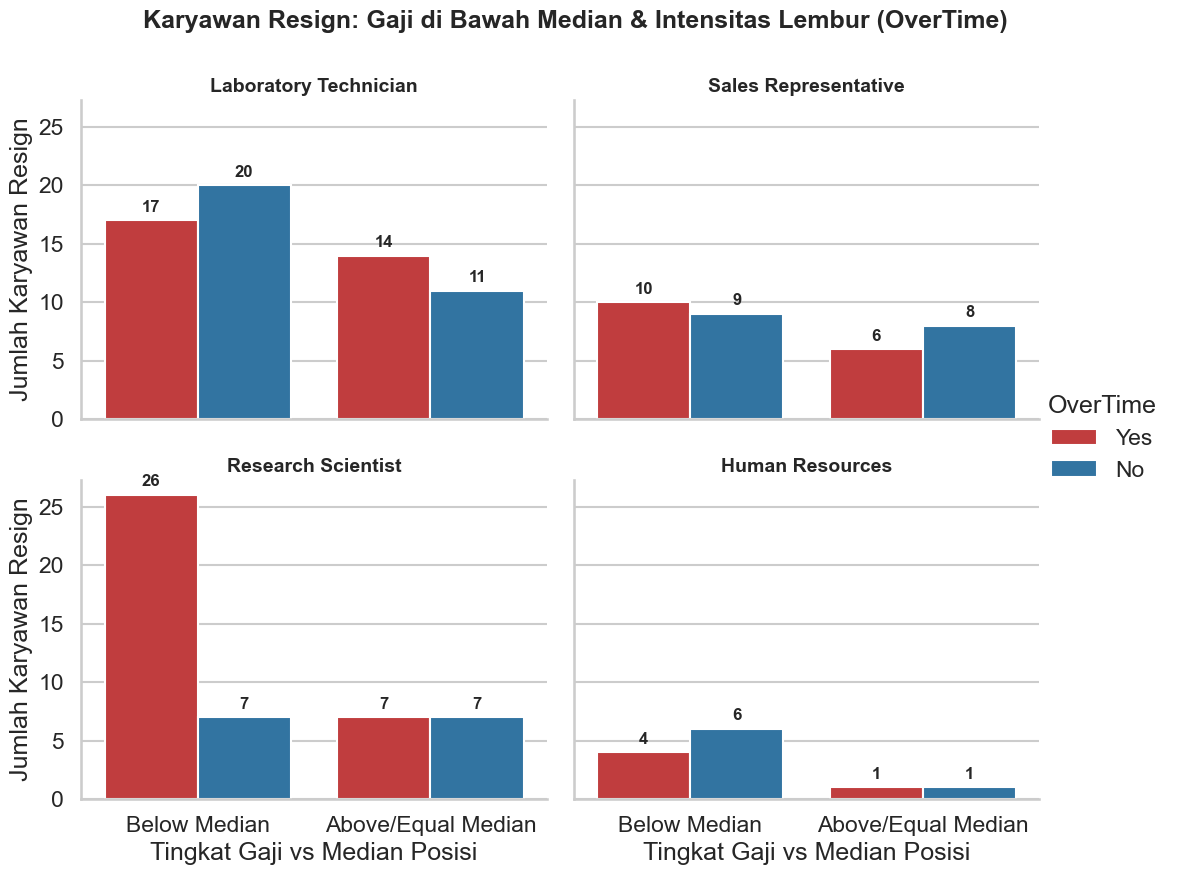

In [42]:
# Karyawan Resign: Gaji di Bawah Median & Intensitas Lembur (OverTime)
# Asumsi dataset utama Anda disimpan dalam variabel 'df'
# (Pastikan dataframe sudah di-load dengan nama 'df' atau ubah sesuai nama variabel Anda)

# 1. Daftar Job Role yang ingin dianalisis secara khusus
target_roles = ['Laboratory Technician', 'Research Scientist', 'Sales Representative', 'Human Resources']

# 2. Filter dataset untuk menghitung Median berdasarkan POPULASI KESELURUHAN tiap role
df_target = data[data['JobRole'].isin(target_roles)].copy()

# 3. Hitung nilai Median Monthly Income untuk masing-masing Job Role
median_incomes = df_target.groupby('JobRole')['MonthlyIncome'].median().to_dict()

# 4. Buat kategori apakah gaji karyawan di bawah median role-nya atau tidak
df_target['Income_vs_Median'] = df_target.apply(
    lambda x: 'Below Median' if x['MonthlyIncome'] < median_incomes[x['JobRole']] else 'Above/Equal Median', 
    axis=1
)

# 5. Ambil HANYA karyawan yang RESIGN (Attrition == 'Yes')
df_resign = df_target[df_target['Attrition'] == 'Yes'].copy()

# 6. Visualisasi menggunakan Seaborn Catplot
sns.set_theme(style="whitegrid", context="talk")
g = sns.catplot(
    data=df_resign,
    x='Income_vs_Median',
    hue='OverTime',
    col='JobRole',
    col_wrap=2,           # Menampilkan 2 kolom grid (2x2)
    kind='count',
    palette={'Yes': '#d62728', 'No': '#1f77b4'}, # Merah untuk lembur, Biru untuk tidak
    height=4.5,
    aspect=1.2,
    order=['Below Median', 'Above/Equal Median'],
    hue_order=['Yes', 'No']
)

# 7. Merapikan judul, label, dan tata letak
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Karyawan Resign: Gaji di Bawah Median & Intensitas Lembur (OverTime)', 
               fontsize=18, fontweight='bold')
g.set_axis_labels("Tingkat Gaji vs Median Posisi", "Jumlah Karyawan Resign")
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# 8. Menambahkan anotasi (angka pasti) di atas setiap bar
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0: # Hanya beri angka jika bar > 0
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        xytext=(0, 4), 
                        textcoords='offset points',
                        fontsize=12, fontweight='bold')

plt.show()


Berdasarkan 2 diagram diatas menunjukan bahwa Hipotesa 2A terbukti valid. Eksodus massal (attrition) pada kelompok peran pekerjaan level junior (Sales Representative, HR, Laboratory Technician, dan Research Scientist) disebabkan oleh kombinasi toksik antara "Kompensasi Jauh di Bawah Rata-Rata" (Underpaid) dan "Tuntutan Jam Kerja Berlebih" (Overworked).

Secara psikologis, mereka sudah menyadari bahwa gaji pokok mereka sangat rendah (berada di dasar piramida kompensasi perusahaan). Ketika perusahaan menuntut mereka untuk terus-menerus lembur, mereka merasa Return of Investment atas waktu dan tenaga mereka sangat tidak sepadan. Beban kerja yang berat tanpa disokong oleh fondasi finansial yang kuat membuat mereka dengan mudah tergiur untuk mencari peluang di perusahaan lain yang menawarkan gaji standar tanpa beban overwork.

Rekomendasi Tindakan: Departemen HR harus segera mengaudit ulang kebijakan lembur untuk Sales Representative dan Lab Technician. Jika beban kerja memang tinggi, perusahaan harus mengubah strategi dari sekadar 'memaksa lembur' menjadi menambah jumlah staf (hiring) atau menyesuaikan ulang rasio upah lembur agar lebih sepadan dengan kelelahan mereka.

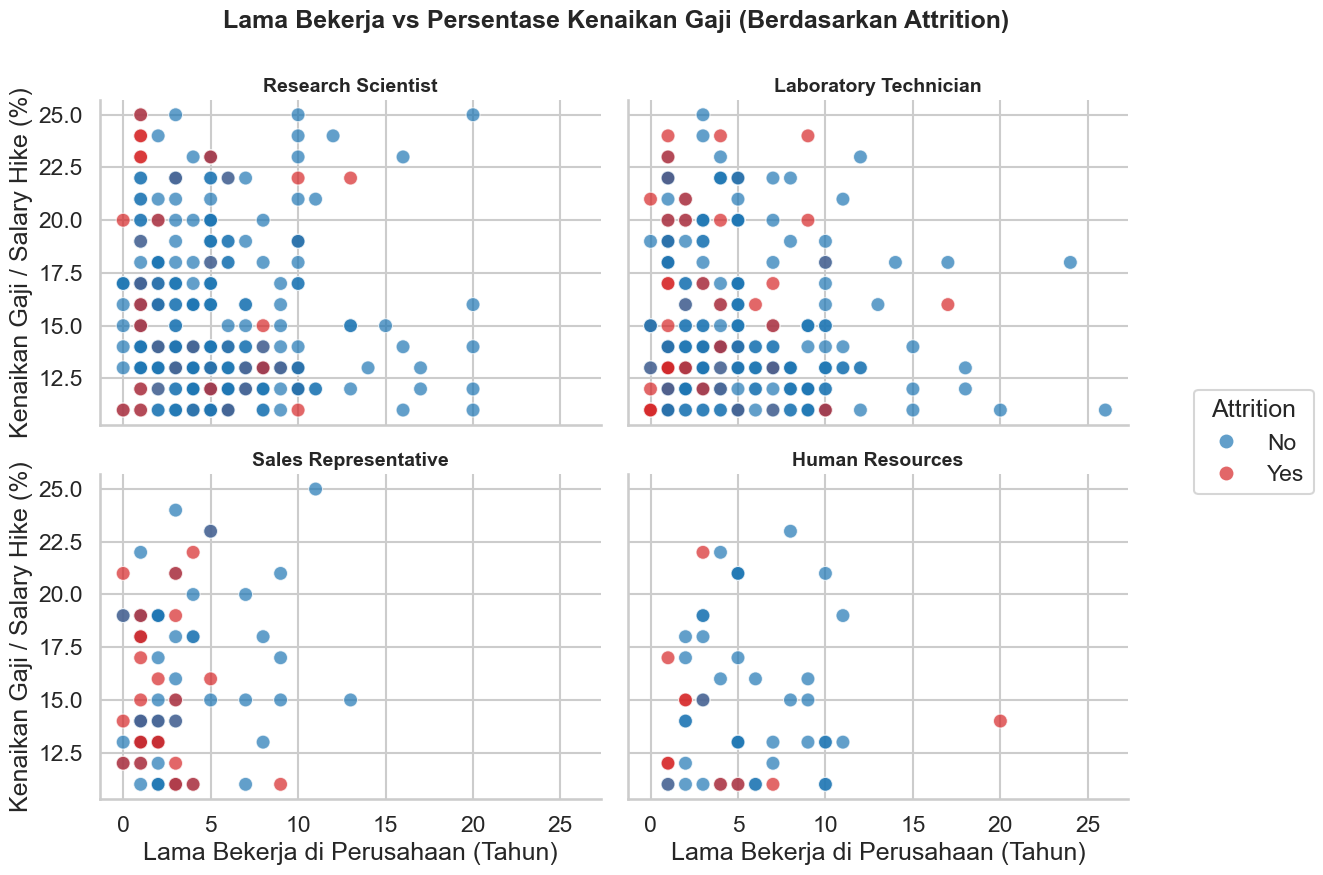

In [46]:
# Lama Bekerja vs Persentase Kenaikan Gaji (Berdasarkan Attrition)
# Asumsi dataset utama Anda disimpan dalam variabel 'df'

# 1. Filter dataset HANYA untuk 4 profesi yang ditargetkan
target_roles = ['Laboratory Technician', 'Research Scientist', 'Sales Representative', 'Human Resources']
df_filtered = data[data['JobRole'].isin(target_roles)]

# 2. Membuat Scatter Plot berbasis Grid (Relplot)
sns.set_theme(style="whitegrid", context="talk")
g = sns.relplot(
    data=df_filtered,
    x='YearsAtCompany',
    y='PercentSalaryHike',
    hue='Attrition',
    col='JobRole',
    col_wrap=2,           # Menampilkan 2 kolom grid
    kind='scatter',
    palette={'Yes': '#d62728', 'No': '#1f77b4'}, # Merah untuk Resign (Yes), Biru untuk Stay (No)
    alpha=0.7,            # Membuat titik sedikit transparan agar terlihat jika bertumpuk
    height=4.5,           # Tinggi tiap panel
    aspect=1.3,           # Lebar tiap panel
    s=100                 # Ukuran titik
)

# 3. Merapikan judul, label, dan tata letak
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Lama Bekerja vs Persentase Kenaikan Gaji (Berdasarkan Attrition)', 
               fontsize=18, fontweight='bold')

g.set_axis_labels("Lama Bekerja di Perusahaan (Tahun)", "Kenaikan Gaji / Salary Hike (%)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# 4. Merapikan legend
# Mengubah letak legend bawaan agar lebih rapi
sns.move_legend(g, "center right", bbox_to_anchor=(1.05, 0.5), title='Attrition', frameon=True)

plt.show()


Berdasarkan diagram diatas menunjukan bahwa Hipotesa 2B Valid : Karyawan junior (Group 1) yang bertahan selama 1 hingga 5 tahun akhirnya memilih resign bukan karena perusahaan pelit menaikkan gaji secara persentase, melainkan karena rasio kenaikan tersebut gagal menutup jurang (gap) defisit gaji pokok mereka dibandingkan harga pasar.

Secara teori HR konvensional, loyalitas seorang karyawan (bertahan 1-5 tahun) seharusnya dibayar dengan kompensasi dan benefit yang membuat mereka berada di atas standar pasar. Namun berbeda dengan mereka enghabiskan bertahun-tahun loyalitasnya bukan untuk mendapatkan reward lebih, melainkan sekadar "mencicil" untuk mencapai standar gaji normal yang seharusnya sudah mereka dapatkan sejak hari pertama bekerja.

menjadi sangat rasional dan pragmatis, daripada harus bertahan selama 3-4 tahun lagi dan menanggung beban lembur berat (OverTime = Yes) hanya agar gaji mereka "normal", jauh lebih masuk akal bagi mereka untuk pindah ke perusahaan kompetitor (jump ship). Pindah perusahaan memungkinkan mereka mendapatkan negosiasi gaji pokok baru dengan lonjakan instan 20-40%, tanpa harus menunggu kenaikan tahunan internal yang tidak mengejar inflasi harga pasar mereka.

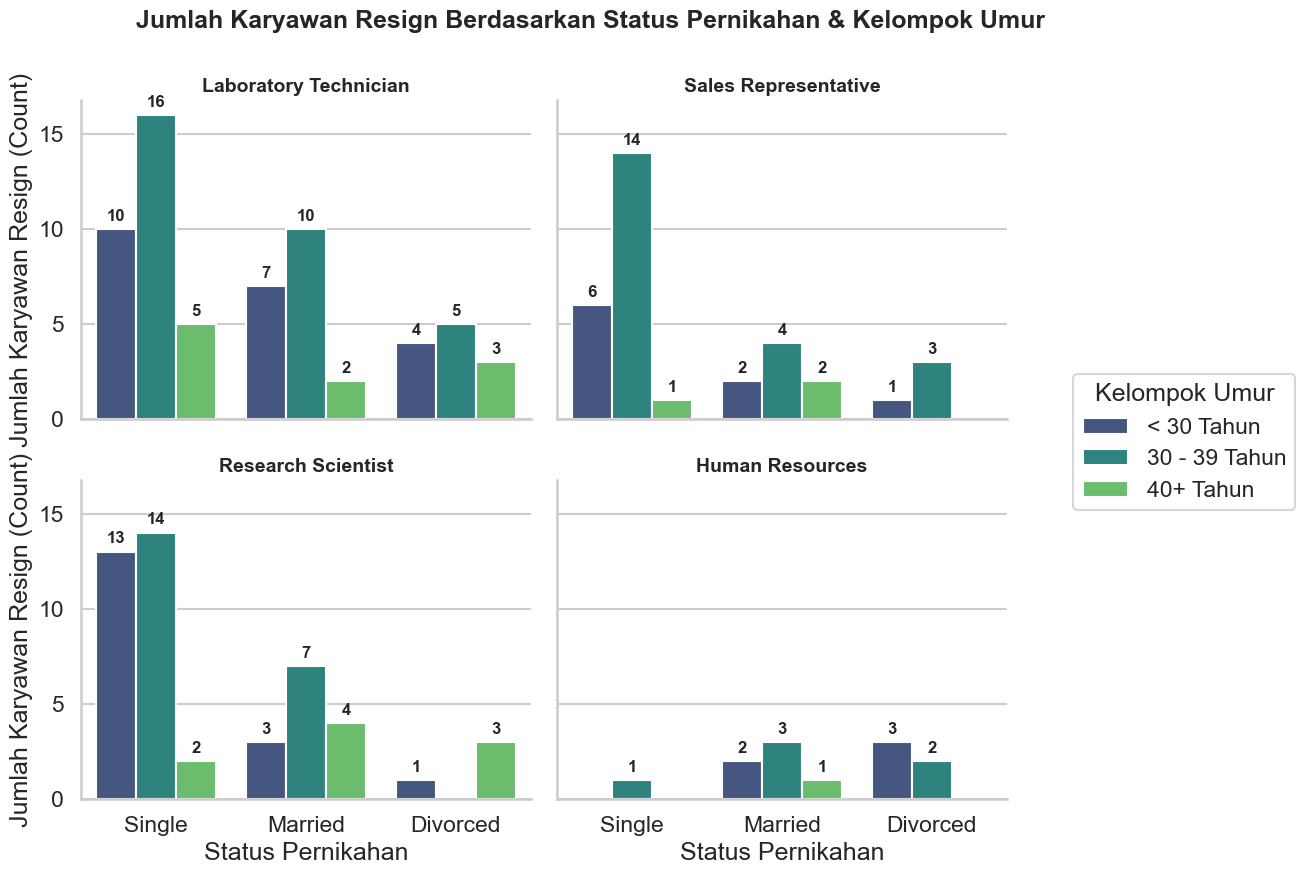

In [48]:
# Jumlah Karyawan Resign Berdasarkan Status Pernikahan & Kelompok Umur
# 1. Filter dataset HANYA untuk 4 profesi yang ditargetkan
target_roles = ['Laboratory Technician', 'Research Scientist', 'Sales Representative', 'Human Resources']
df_filtered = data[data['JobRole'].isin(target_roles)].copy()

# 2. Mengelompokkan Umur (Age) ke dalam kategori agar rapi saat dihitung jumlahnya (Count)
df_filtered['Age_Group'] = pd.cut(df_filtered['Age'], 
                                  bins=[0, 29, 39, 100], 
                                  labels=['< 30 Tahun', '30 - 39 Tahun', '40+ Tahun'])

# 3. Fokus HANYA pada karyawan yang RESIGN (Attrition == 'Yes')
df_resign = df_filtered[df_filtered['Attrition'] == 'Yes']

# 4. Membuat Bar Chart (Countplot)
sns.set_theme(style="whitegrid", context="talk")

g = sns.catplot(
    data=df_resign,
    x='MaritalStatus',    # Sumbu X adalah status pernikahan
    hue='Age_Group',      # Warna bar membedakan kelompok umur
    col='JobRole',
    col_wrap=2,           # Menampilkan 2 kolom grid (2x2)
    kind='count',         # Menampilkan diagram JUMLAH (Count)
    palette='viridis',    # Palet warna gradasi yang elegan
    height=4.5,
    aspect=1.2,
    order=['Single', 'Married', 'Divorced']
)

# 5. Merapikan judul, label, dan tata letak
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Jumlah Karyawan Resign Berdasarkan Status Pernikahan & Kelompok Umur', 
               fontsize=18, fontweight='bold')

g.set_axis_labels("Status Pernikahan", "Jumlah Karyawan Resign (Count)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# 6. Menambahkan anotasi (angka pasti) di atas setiap bar agar jelas
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0: # Hanya print angka jika jumlahnya > 0
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        xytext=(0, 4), 
                        textcoords='offset points',
                        fontsize=12, fontweight='bold')

# 7. Merapikan legend
sns.move_legend(g, "center right", bbox_to_anchor=(1.05, 0.5), title='Kelompok Umur', frameon=True)

plt.show()


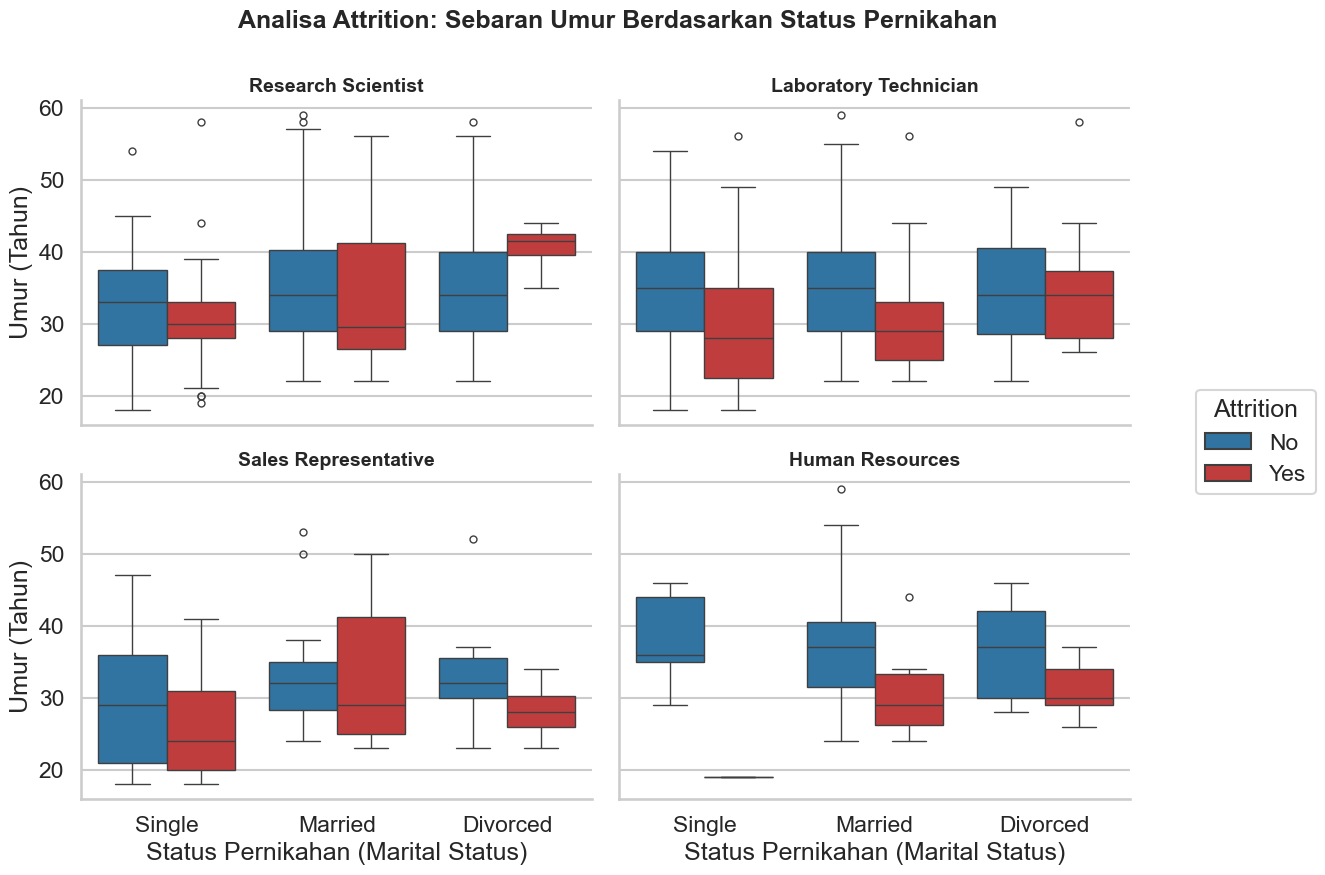

In [47]:
# Analisa Attrition: Sebaran Umur Berdasarkan Status Pernikahan
# Asumsi dataset utama Anda disimpan dalam variabel 'df'

# 1. Filter dataset HANYA untuk 4 profesi yang ditargetkan
target_roles = ['Laboratory Technician', 'Research Scientist', 'Sales Representative', 'Human Resources']
df_filtered = data[data['JobRole'].isin(target_roles)]

# 2. Membuat Box Plot berbasis Grid (Catplot)
sns.set_theme(style="whitegrid", context="talk")

g = sns.catplot(
    data=df_filtered,
    x='MaritalStatus',
    y='Age',
    hue='Attrition',
    col='JobRole',
    col_wrap=2,           # Menampilkan 2 kolom grid
    kind='box',           # Menggunakan Box Plot untuk melihat sebaran umur
    palette={'Yes': '#d62728', 'No': '#1f77b4'}, # Merah (Resign), Biru (Stay)
    height=4.5,
    aspect=1.3,
    order=['Single', 'Married', 'Divorced'] # Mengurutkan status agar lebih masuk akal
)

# 3. Merapikan judul, label, dan tata letak
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Analisa Attrition: Sebaran Umur Berdasarkan Status Pernikahan', 
               fontsize=18, fontweight='bold')

g.set_axis_labels("Status Pernikahan (Marital Status)", "Umur (Tahun)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# 4. Merapikan legend
sns.move_legend(g, "center right", bbox_to_anchor=(1.05, 0.5), title='Attrition', frameon=True)

plt.show()


Berdasarkan 2 diagram diatas menunjukan bahwa Hipotesa 2C Valid: Status Single adalah katalisator utama tingginya angka resign di Group 1. Eksodus ini didominasi oleh demografi usia muda yang tidak memiliki "jangkar" finansial keluarga, sehingga mereka memiliki toleransi yang sangat rendah terhadap kompensasi di bawah standar.

Secara demografis, karyawan Single di usia 20-an (Gen Z / Milenial Awal) berada di fase eksplorasi karier dengan keberanian mengambil risiko (risk appetite) yang ekstrem. Mereka tidak ada jangkar finansial & Sangat rasiona, Ketika mereka menyadari bahwa posisi mereka (Sales Rep, Lab Tech, dll) digaji jauh di bawah rata-rata pasar dengan beban kerja yang berat, mereka tidak punya alasan moral atau ketakutan finansial untuk bertahan.

REKOMENDASI STRATEGIS: MITIGASI KEBOCORAN TALENTA (TALENT BLEED) PADA POSISI JUNIOR

Berdasarkan temuan data, perusahaan saat ini menghadapi krisis retensi pada kelompok posisi junior operasional (Sales Representative, Laboratory Technician, Research Scientist, dan Human Resources). Kombinasi antara gaji pokok di bawah standar pasar, eksploitasi jam lembur, dan lambatnya eskalasi karir telah memicu eksodus masif.

Karyawan di segmen ini (mayoritas berusia 20-an dan berstatus Single) memiliki toleransi risiko yang tinggi. Data membuktikan mereka rata-rata hanya bertahan 1 hingga 5 tahun—waktu yang cukup bagi mereka untuk menyerap ilmu dan pengalaman, sebelum akhirnya dibajak oleh kompetitor. Jika dibiarkan, perusahaan secara tidak langsung hanya beroperasi sebagai "tempat training gratis" bagi industri, dan terus membakar biaya rekrutmen setiap tahunnya.

Untuk menghentikan siklus kerugian ini, kami merekomendasikan 3 Pilar Aksi Strategis berikut:

PILAR 1: Restrukturisasi Fundamental Kompensasi (Market Adjustment)
Sistem kenaikan gaji tahunan (merit increase) terbukti gagal menahan laju turnover karena fondasi gaji pokok (base salary) kelompok ini sudah terlalu rendah sejak awal.

- Lakukan Market Adjustment (Penyesuaian Pasar) Segera: Manajemen perlu mengubah strategi dari sekadar memberikan persentase kenaikan tahunan menjadi melakukan kalibrasi gaji pokok secara fundamental. Gaji pokok untuk peran krusial ini harus dinaikkan setidaknya mendekati persentil ke-50 (P50) dari rata-rata industri.

- Terapkan Pay Transparency (Transparansi Jenjang Kompensasi): Karyawan muda sering resign karena merasa masa depannya di perusahaan tidak pasti. HR harus membangun roadmap kompensasi yang jelas (misal: "Setelah 2 tahun masa bakti dengan KPI tercapai, gaji pokok Anda otomatis disesuaikan ke standar level Mid"). Harapan yang konkret akan mencegah mereka mencari kepastian di perusahaan lain.

PILAR 2: Audit Kapasitas Beban Kerja & Regulasi Lembur
Lembur (OverTime) yang berkepanjangan pada karyawan bergaji rendah adalah pemicu utama burnout. Tingkat pengunduran diri pada karyawan Single melonjak hingga di atas 70% ketika mereka diwajibkan lembur terus-menerus.

- Investigasi Praktik "Single Tax" di Lapangan: Lakukan audit terhadap distribusi jam lembur. Pastikan manajer lini tidak membebankan beban kerja tidak proporsional kepada karyawan berstatus Single hanya karena asumsi bahwa mereka "tidak memiliki urgensi keluarga di rumah".

- Konversi Anggaran Lembur Menjadi Penambahan Staf (Headcount): Evaluasi kembali total biaya lembur yang dibayarkan ke kelompok ini. Jika biaya lembur ditambah biaya rekrutmen ulang (akibat karyawan resign) sudah melampaui batas kewajaran, jauh lebih efisien secara finansial untuk merekrut staf baru (hiring) guna membagi beban kerja secara adil dan menekan angka burnout.

PILAR 3: Kustomisasi Paket Retensi (The "New Golden Handcuffs")
Paket benefit tradisional (seperti asuransi keluarga atau tunjangan anak) tidak memiliki daya tarik retensi bagi demografi anak muda yang berstatus Single. Perusahaan harus menciptakan "jangkar" yang relevan dengan fase hidup mereka.

- Terapkan Flexible Benefit: Alihkan anggaran benefit keluarga yang tidak mereka gunakan ke program yang lebih relevan bagi pengembangan diri mereka. Misalnya: Subsidi sertifikasi profesional, fasilitas kebugaran (gym), atau fleksibilitas jam kerja / Remote Working parsial.

- Skema Bonus Retensi Jangka Menengah: Buat skema insentif berupa Retention Bonus atau pembagian saham kecil (Micro-Equity) yang baru bisa dicairkan (vesting) pada tahun ke-3 atau ke-4 masa kerja. Hal ini akan menciptakan Opportunity Cost (biaya kerugian) yang signifikan di benak karyawan jika mereka berniat resign lebih awal.

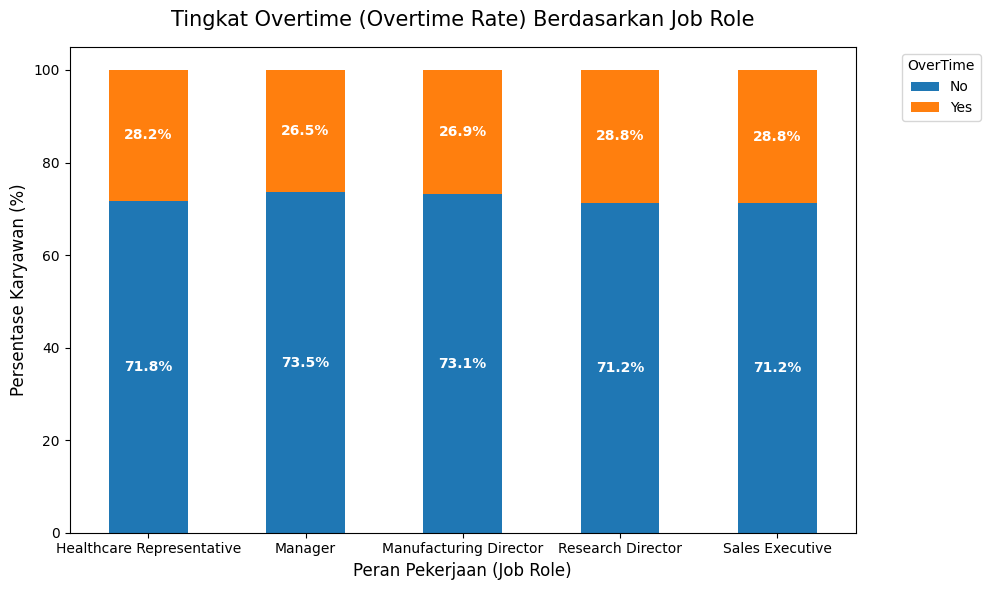

In [32]:
# 1. Memfilter data hanya untuk 3 peran (JobRole) yang diminta
target_roles = ['Sales Executive', 'Manufacturing Director', 'Healthcare Representative', 'Manager','Research Director']
df_filtered = data[data['JobRole'].isin(target_roles)]
# 2. Menghitung rate / persentase OverTime untuk setiap JobRole
# normalize='index' otomatis menghitung proporsi per kategori JobRole (total = 1 atau 100%)
overtime_rate = pd.crosstab(df_filtered['JobRole'], df_filtered['OverTime'], normalize='index') * 100
# 3. Membuat diagram batang bertumpuk (stacked bar chart)
# Warna biru ('#1f77b4') biasanya untuk 'No', oranye ('#ff7f0e') untuk 'Yes'
ax = overtime_rate.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
# 4. Kustomisasi judul dan label
plt.title('Tingkat Overtime (Overtime Rate) Berdasarkan Job Role', fontsize=15, pad=15)
plt.xlabel('Peran Pekerjaan (Job Role)', fontsize=12)
plt.ylabel('Persentase Karyawan (%)', fontsize=12)
plt.xticks(rotation=0) # Memastikan teks sumbu X tetap horizontal
# 5. Menambahkan teks angka persentase di tengah-tengah setiap blok warna
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Hanya menambahkan teks jika persentasenya > 0
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white', 
                fontweight='bold')
# Merapikan legend agar letaknya di luar kotak grafik
plt.legend(title='OverTime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# Menampilkan grafik
plt.show()


berdasarkan data diatas menunjukan beberapa role yang keluar tidak didasari gaji itu memiliki tingkat overtime / lembur di atas 25%

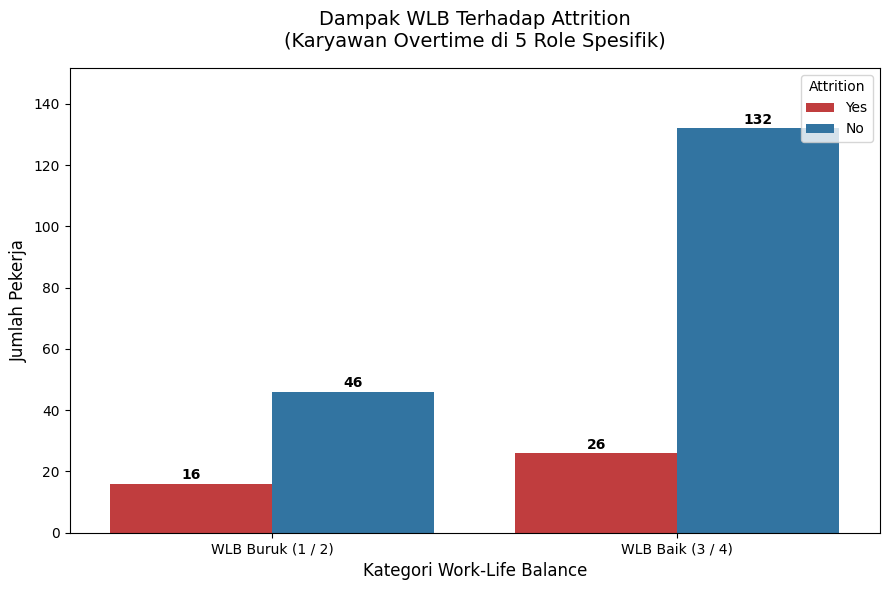

In [33]:
# 1. Tentukan JobRole yang ingin difokuskan
target_roles = [
    'Sales Executive', 
    'Manufacturing Director', 
    'Healthcare Representative', 
    'Manager', 
    'Research Director'
]

# 2. Filter: Harus OverTime = 'Yes' DAN JobRole ada di dalam target_roles
df_filtered = data[(data['OverTime'] == 'Yes') & (data['JobRole'].isin(target_roles))].copy()

# 3. Buat fungsi untuk mengelompokkan WorkLifeBalance
def kategorikan_wlb(nilai):
    if nilai in [3, 4]:
        return 'WLB Baik (3 / 4)'
    elif nilai in [1, 2]:
        return 'WLB Buruk (1 / 2)'

# [PERBAIKAN BUG]: Terapkan pada df_filtered, bukan variabel df_ot_yes yang lama
df_filtered['Kategori_WLB'] = df_filtered['WorkLifeBalance'].apply(kategorikan_wlb)

# 4. Membuat visualisasi Bar Chart (Gunakan countplot agar Attrition bisa jadi Hue)
plt.figure(figsize=(9, 6))

# sns.countplot otomatis menghitung jumlah kemunculan data dan memisahkannya
ax = sns.countplot(
    data=df_filtered, 
    x='Kategori_WLB', 
    hue='Attrition', 
    palette={'No': '#1f77b4', 'Yes': '#d62728'} # Biru untuk Stay (No), Merah untuk Resign (Yes)
)

# 5. Kustomisasi judul dan label
plt.title('Dampak WLB Terhadap Attrition\n(Karyawan Overtime di 5 Role Spesifik)', fontsize=14, pad=15)
plt.xlabel('Kategori Work-Life Balance', fontsize=12)
plt.ylabel('Jumlah Pekerja', fontsize=12)

# 6. Menambahkan angka aktual di atas setiap balok grafik
for p in ax.patches:
    height = p.get_height()
    # sns.countplot mengembalikan nilai NaN jika ada kombinasi yang kebetulan 0 orang, jadi kita cek math.isnan
    if not math.isnan(height) and height > 0:
        ax.text(p.get_x() + p.get_width()/2., 
                height + 0.5, # Padding tipis di atas kotak
                f'{int(height)}', 
                ha='center', 
                va='bottom', 
                fontweight='bold')

# Mencari tinggi balok maksimal untuk memberikan ruang lega di area atas plot
maksimal_tinggi = df_filtered.groupby(['Kategori_WLB', 'Attrition']).size().max()
plt.ylim(0, maksimal_tinggi * 1.15)

# 7. Memastikan Legend Attrition muncul dengan rapi di pojok kanan atas grafik
plt.legend(title='Attrition', loc='upper right')

plt.tight_layout()
plt.show()


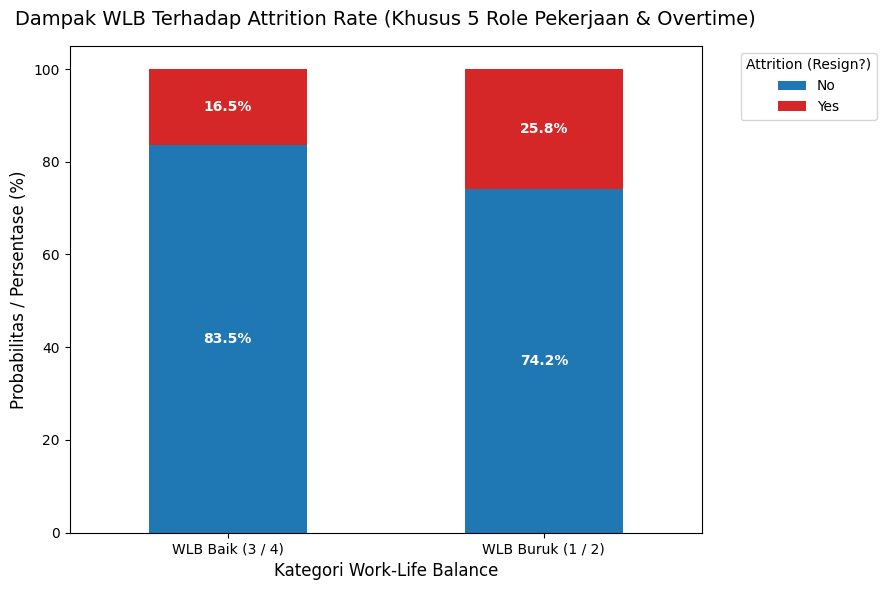

In [34]:
# 1. Tentukan JobRole yang ingin difokuskan
target_roles = [
    'Sales Executive', 
    'Manufacturing Director', 
    'Healthcare Representative', 
    'Manager', 
    'Research Director'
]
# 2. Filter: Harus OverTime = 'Yes' DAN JobRole ada di dalam daftar di atas
df_filtered = data[(data['OverTime'] == 'Yes') & (data['JobRole'].isin(target_roles))].copy()
# 3. Pengelompokan WorkLifeBalance menjadi 2 Kategori
def kategorikan_wlb(nilai):
    if nilai in [3, 4]:
        return 'WLB Baik (3 / 4)'
    elif nilai in [1, 2]:
        return 'WLB Buruk (1 / 2)'
df_filtered['Kategori_WLB'] = df_filtered['WorkLifeBalance'].apply(kategorikan_wlb)
# 4. Hitung probabilitas/rate Attrition
# normalize='index' akan menghitung persentase per baris (per kategori WLB)
attrition_rates = pd.crosstab(df_filtered['Kategori_WLB'], df_filtered['Attrition'], normalize='index') * 100
# 5. Membuat visualisasi Stacked Bar Chart
warna_attrition = {'No': '#1f77b4', 'Yes': '#d62728'} 
ax = attrition_rates.plot(kind='bar', stacked=True, figsize=(9, 6), color=[warna_attrition.get(col, '#333') for col in attrition_rates.columns])
# 6. Kustomisasi judul dan sumbu
plt.title('Dampak WLB Terhadap Attrition Rate (Khusus 5 Role Pekerjaan & Overtime)', fontsize=14, pad=15)
plt.xlabel('Kategori Work-Life Balance', fontsize=12)
plt.ylabel('Probabilitas / Persentase (%)', fontsize=12)
plt.xticks(rotation=0)
# 7. Menambahkan angka persentase
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')
plt.legend(title='Attrition (Resign?)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

berdasarkan 2 diagram diatas, kami menyimpulkan bahwa overtime / lembur yang diiringi dengan tingkat worklifebalance yang baik bisa menurunkan tingkat attrition secara signifikan sekitar 9%

### 

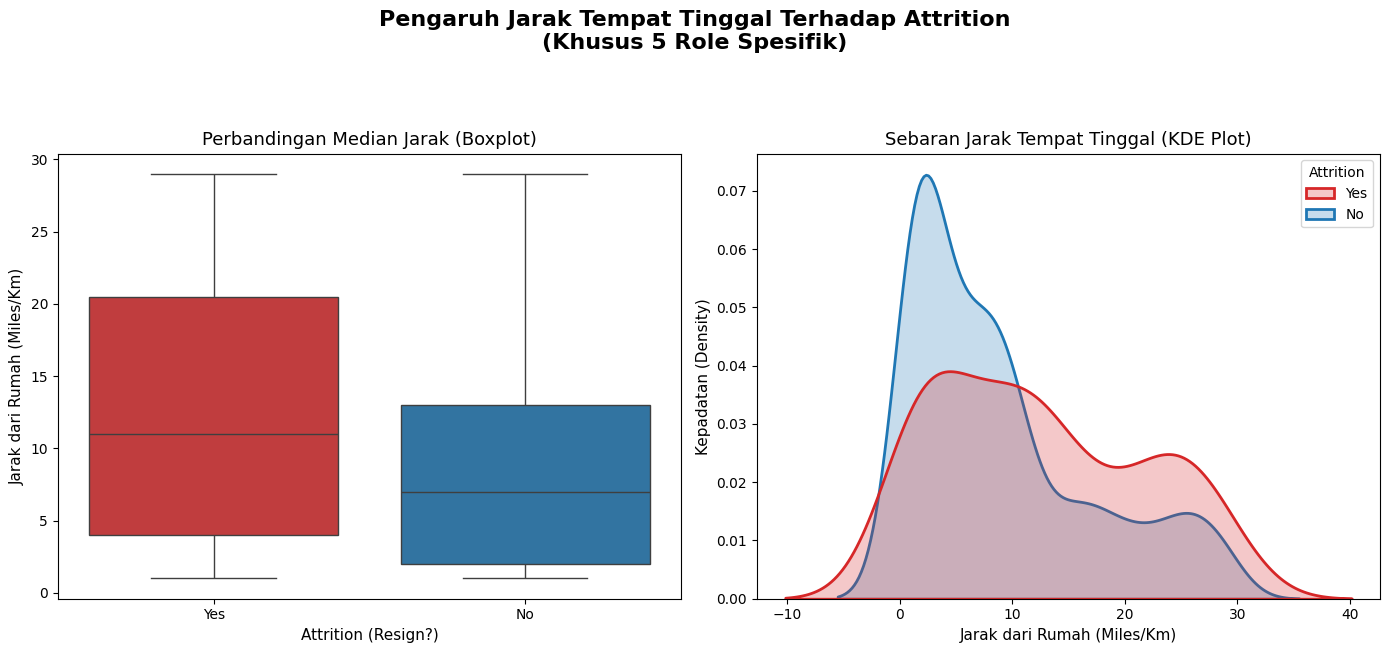

In [35]:
# 1. Tentukan JobRole yang difokuskan
target_roles = [
    'Sales Executive', 
    'Manufacturing Director', 
    'Healthcare Representative', 
    'Manager', 
    'Research Director'
]

# 2. Filter data khusus untuk 5 JobRole tersebut
df_jarak = data[data['JobRole'].isin(target_roles)].copy()

# 3. Siapkan Kanvas untuk 2 Grafik Berdampingan (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapping warna: Biru untuk Stay (No), Merah untuk Resign (Yes)
warna_attrition = {'No': '#1f77b4', 'Yes': '#d62728'}

# ==========================================
# GRAFIK 1 (Kiri): BOXPLOT
# ==========================================
# Tambahkan hue='Attrition' dan legend=False untuk mencegah FutureWarning
sns.boxplot(
    ax=axes[0],
    data=df_jarak, 
    x='Attrition', 
    y='DistanceFromHome', 
    hue='Attrition', 
    palette=warna_attrition,
    legend=False
)
axes[0].set_title('Perbandingan Median Jarak (Boxplot)', fontsize=13)
axes[0].set_xlabel('Attrition (Resign?)', fontsize=11)
axes[0].set_ylabel('Jarak dari Rumah (Miles/Km)', fontsize=11)


# ==========================================
# GRAFIK 2 (Kanan): KDE / DENSITY PLOT
# ==========================================
sns.kdeplot(
    ax=axes[1],
    data=df_jarak, 
    x='DistanceFromHome', 
    hue='Attrition', 
    fill=True, 
    palette=warna_attrition,
    linewidth=2,
    # common_norm=False memastikan luas kedua gunung adalah 100%
    # (Penting agar gunung warna merah tidak terlihat sangat kecil hanya karena jumlah yg resign lebih sedikit)
    common_norm=False 
)
axes[1].set_title('Sebaran Jarak Tempat Tinggal (KDE Plot)', fontsize=13)
axes[1].set_xlabel('Jarak dari Rumah (Miles/Km)', fontsize=11)
axes[1].set_ylabel('Kepadatan (Density)', fontsize=11)


# 4. Kustomisasi Layout Keseluruhan
plt.suptitle("Pengaruh Jarak Tempat Tinggal Terhadap Attrition\n(Khusus 5 Role Spesifik)", 
             fontsize=16, y=1.08, fontweight='bold')

plt.tight_layout()
plt.show()


berdasarkan diagram diatas. secara karyawan yang resign memiliki median jarak yg lebih jauh  dibandingkan mereka yang stay di perusahaan.

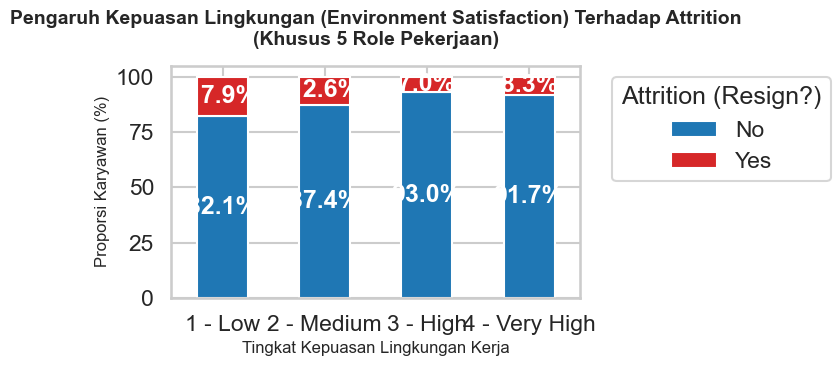

In [53]:
# 1. Tentukan JobRole yang difokuskan
target_roles = [
    'Sales Executive', 
    'Manufacturing Director', 
    'Healthcare Representative', 
    'Manager', 
    'Research Director'
]

# 2. Filter data khusus untuk 5 JobRole tersebut
df_env = data[data['JobRole'].isin(target_roles)].copy()

# 3. Ubah angka menjadi teks agar grafik lebih informatif (Standar IBM HR Dataset)
label_kepuasan = {
    1: '1 - Low',
    2: '2 - Medium',
    3: '3 - High',
    4: '4 - Very High'
}
df_env['EnvSatisfaction_Label'] = df_env['EnvironmentSatisfaction'].map(label_kepuasan)

# 4. Hitung PERSENTASE Attrition (Stay vs Resign) di setiap level kepuasan
# normalize='index' akan membagi persentase (total 100%) untuk masing-masing level rating
attrition_rate = pd.crosstab(df_env['EnvSatisfaction_Label'], df_env['Attrition'], normalize='index') * 100

# 5. Membuat Visualisasi Stacked Bar Chart
warna_attrition = {'No': '#1f77b4', 'Yes': '#d62728'} 
warna_list = [warna_attrition.get(col, '#333') for col in attrition_rate.columns]

ax = attrition_rate.plot(kind='bar', stacked=True, figsize=(8, 4), color=warna_list)

# 6. Kustomisasi Judul dan Label Sumbu
plt.title("Pengaruh Kepuasan Lingkungan (Environment Satisfaction) Terhadap Attrition\n(Khusus 5 Role Pekerjaan)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Tingkat Kepuasan Lingkungan Kerja', fontsize=12)
plt.ylabel('Proporsi Karyawan (%)', fontsize=12)
plt.xticks(rotation=0)

# 7. Menambahkan angka persentase di tengah batang grafik
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Hindari menampilkan teks untuk persentase 0%
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')

plt.legend(title='Attrition (Resign?)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


berdasarkan diagram ini, tingkat kepuasan lingkungan kerja yang baik dapat menurunkan attrition rate sekitar 5 - 9%

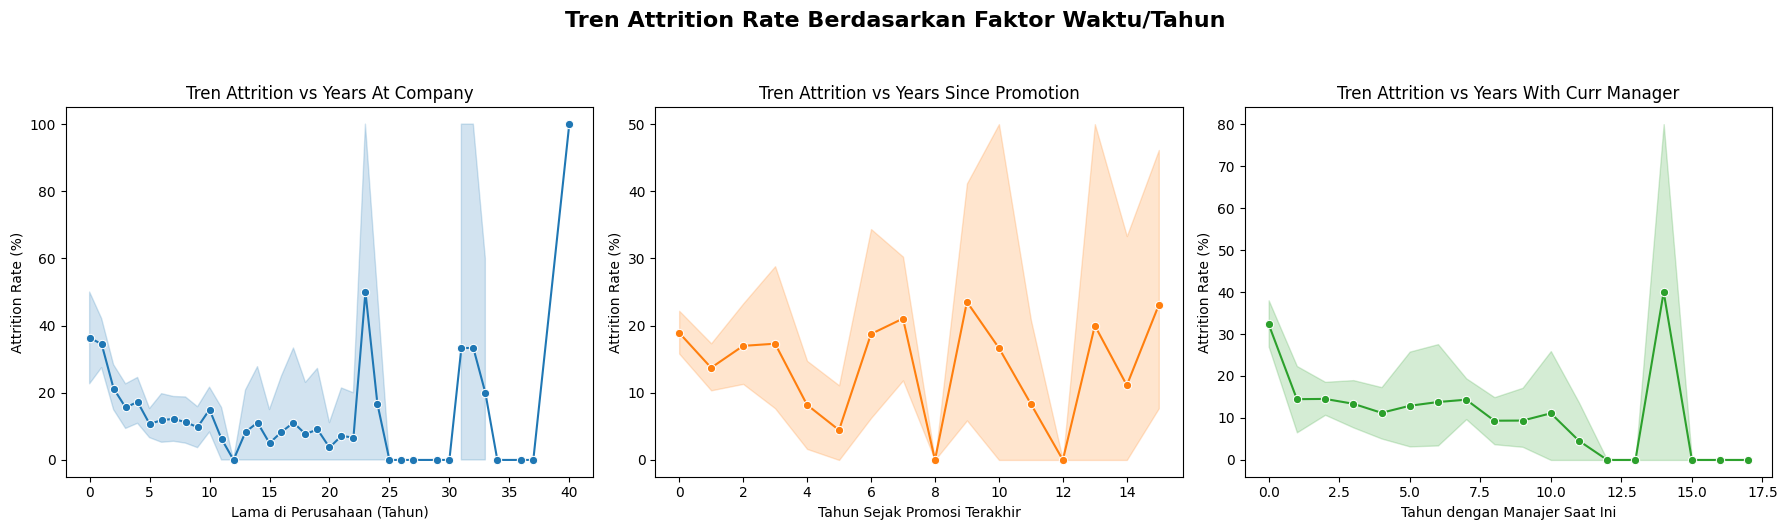

In [37]:
# 1. Konversi 'Attrition' menjadi angka persentase sementara
# 'Yes' dihitung 100%, 'No' dihitung 0%. Rata-ratanya otomatis akan menjadi Attrition Rate.
data['Attrition_Rate_Pct'] = data['Attrition'].map({'Yes': 100, 'No': 0})
# 2. Membuat kanvas Subplot (1 baris, 3 kolom) agar sejajar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# --- Plot 1: YearsAtCompany ---
sns.lineplot(ax=axes[0], data=data, x='YearsAtCompany', y='Attrition_Rate_Pct', marker='o', color='#1f77b4')
axes[0].set_title('Tren Attrition vs Years At Company')
axes[0].set_xlabel('Lama di Perusahaan (Tahun)')
axes[0].set_ylabel('Attrition Rate (%)')
# --- Plot 2: YearsSinceLastPromotion ---
sns.lineplot(ax=axes[1], data=data, x='YearsSinceLastPromotion', y='Attrition_Rate_Pct', marker='o', color='#ff7f0e')
axes[1].set_title('Tren Attrition vs Years Since Promotion')
axes[1].set_xlabel('Tahun Sejak Promosi Terakhir')
axes[1].set_ylabel('Attrition Rate (%)')
# --- Plot 3: YearsWithCurrManager ---
sns.lineplot(ax=axes[2], data=data, x='YearsWithCurrManager', y='Attrition_Rate_Pct', marker='o', color='#2ca02c')
axes[2].set_title('Tren Attrition vs Years With Curr Manager')
axes[2].set_xlabel('Tahun dengan Manajer Saat Ini')
axes[2].set_ylabel('Attrition Rate (%)')
# 3. Kustomisasi layout keseluruhan
plt.suptitle('Tren Attrition Rate Berdasarkan Faktor Waktu/Tahun', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
# 4. (Opsional) Hapus kolom bantuan agar dataset tetap bersih seperti semula
data.drop('Attrition_Rate_Pct', axis=1, inplace=True)

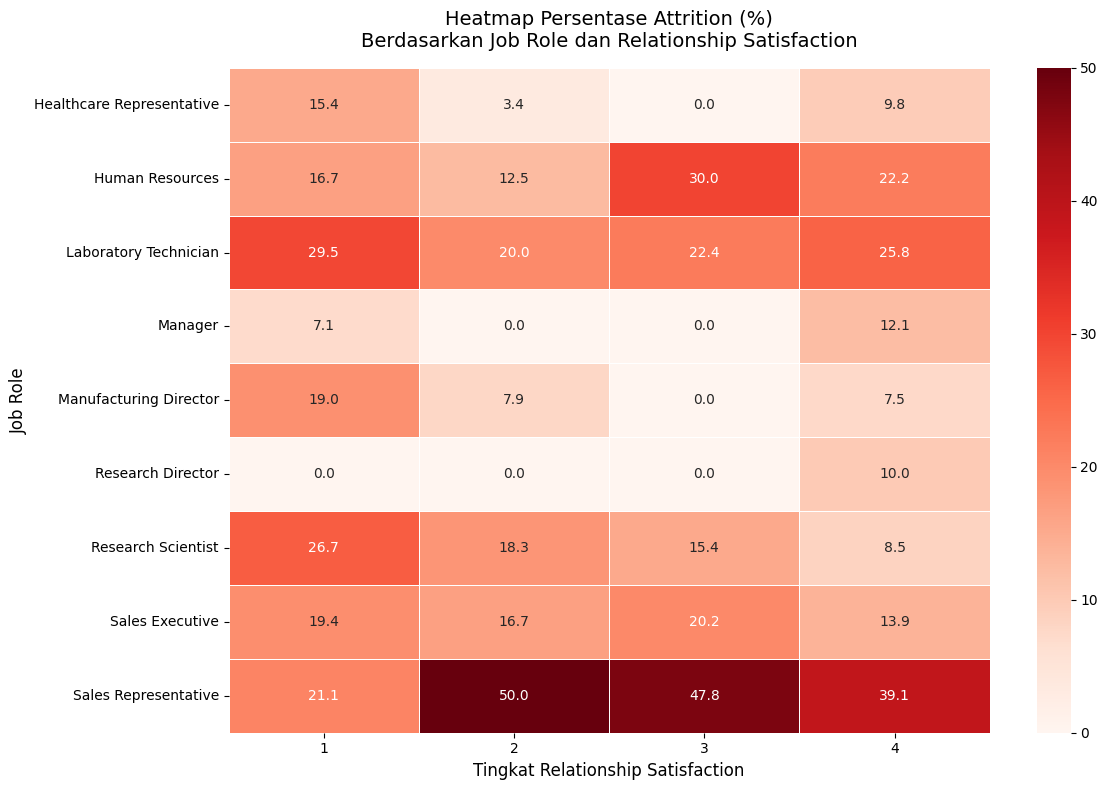

In [20]:
# Heatmap Persentase Attrition Berdasarkan Job Role dan Relationship Satisfaction
# 1. Mengubah Attrition menjadi angka sementara (Yes=1, No=0)
df_temp = data.copy()
df_temp['Attrition_Num'] = df_temp['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Pivot Table dengan RelationshipSatisfaction
pivot_data = df_temp.pivot_table(
    index='JobRole', 
    columns='RelationshipSatisfaction',   # <--- Diubah di sini
    values='Attrition_Num', 
    aggfunc='mean'
) * 100

# 3. Menggambar Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)

# Menyesuaikan Judul dan Label
plt.title('Heatmap Persentase Attrition (%)\nBerdasarkan Job Role dan Relationship Satisfaction', fontsize=14, pad=15)
plt.xlabel('Tingkat Relationship Satisfaction', fontsize=12) # <--- Diubah di sini
plt.ylabel('Job Role', fontsize=12)

plt.tight_layout()
plt.show()


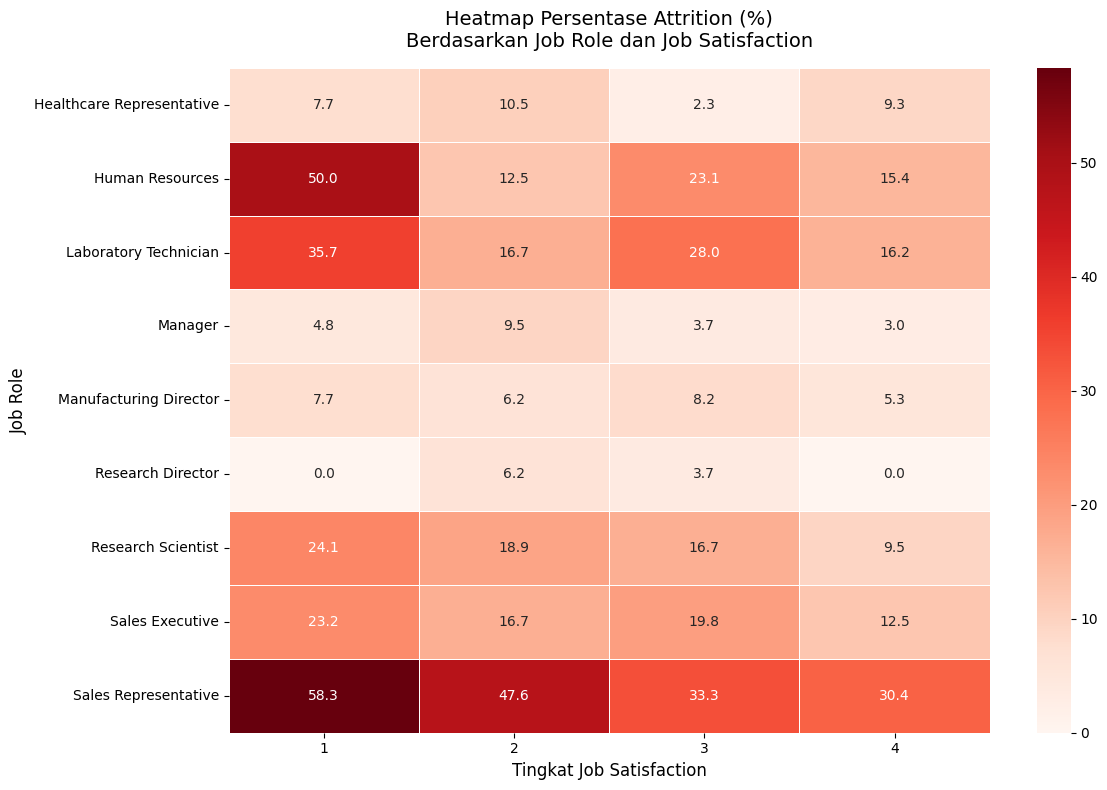

In [40]:
# Heatmap Persentase Attrition Berdasarkan Job Role dan Job Satisfaction
# 1. Kita buat kolom sementara untuk mengubah Attrition menjadi angka (Yes=1, No=0)
# Tujuannya agar kita bisa menghitung persentase/rata-ratanya dengan mudah
df_temp = data.copy()
df_temp['Attrition_Num'] = df_temp['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Membuat Pivot Table (Baris: JobRole, Kolom: JobSatisfaction, Nilai: % Attrition)
pivot_data = df_temp.pivot_table(
    index='JobRole', 
    columns='JobSatisfaction', 
    values='Attrition_Num', 
    aggfunc='mean'
) * 100  # Dikali 100 agar menjadi persentase

# 3. Menggambar Heatmap
plt.figure(figsize=(12, 8))
# annot=True untuk menampilkan angka persentase di dalam kotak
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)

plt.title('Heatmap Persentase Attrition (%)\nBerdasarkan Job Role dan Job Satisfaction', fontsize=14, pad=15)
plt.xlabel('Tingkat Job Satisfaction', fontsize=12)
plt.ylabel('Job Role', fontsize=12)

plt.tight_layout()
plt.show()


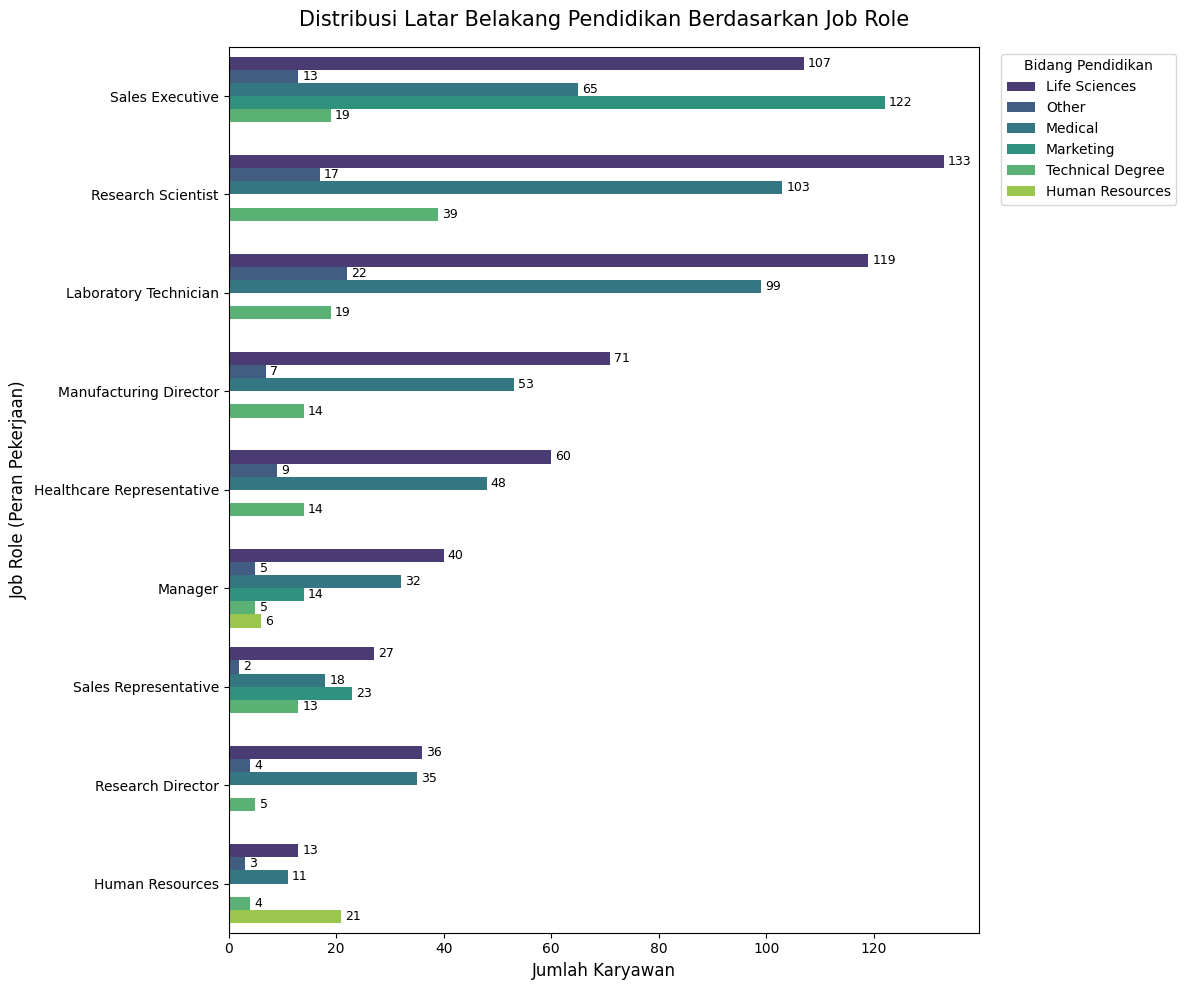

In [38]:
# Distribusi Latar Belakang Pendidikan Berdasarkan Job Role
# Mengatur ukuran kanvas menjadi lebih tinggi (12x10) karena jumlah JobRole cukup banyak
plt.figure(figsize=(12, 10))
# Membuat diagram batang horizontal (Kita menaruh 'JobRole' di sumbu Y, bukan X)
ax = sns.countplot(data=data, y='JobRole', hue='EducationField', palette='viridis')
# --- MENAMBAHKAN DATA LABEL ---
# Menambahkan label angka pada setiap batang
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
# ------------------------------
# Menambahkan judul dan label sumbu
plt.title('Distribusi Latar Belakang Pendidikan Berdasarkan Job Role', fontsize=15, pad=15)
plt.xlabel('Jumlah Karyawan', fontsize=12)
plt.ylabel('Job Role (Peran Pekerjaan)', fontsize=12)
# Menyesuaikan posisi legenda agar tidak menutupi diagram
plt.legend(title='Bidang Pendidikan', bbox_to_anchor=(1.02, 1), loc='upper left')
# Agar layout menyesuaikan dengan rapi
plt.tight_layout()
# Menampilkan grafik
plt.show()

In [17]:
# Jumlah Attrition Kolom Numerikal
# 1. Tentukan kolom-kolom yang ingin dianalisis
rating_cols = [
    'WorkLifeBalance', 
    'RelationshipSatisfaction',
    'EnvironmentSatisfaction', 
    'JobSatisfaction', 
    'JobInvolvement',
    'JobLevel',
    'StockOptionLevel',       
    'YearsWithCurrManager',
    'YearsSinceLastPromotion',
    'YearsInCurrentRole',
    'YearsAtCompany',          # <--- PERBAIKAN 1: Tambahkan koma di sini
    'DistanceFromHome',
    'NumCompaniesWorked',
    'TotalWorkingYears',       # <--- PERBAIKAN 2: Tambahkan huruf 'r' di sini
    'PerformanceRating',
    'TrainingTimesLastYear',
]

# 2. Lakukan perulangan (looping)
for kolom in rating_cols:
    print(f"=== Jumlah Attrition Berdasarkan: {kolom} ===")
    
    # Gunakan crosstab tanpa parameter normalize untuk mendapatkan jumlah (count)
    tabel_count = pd.crosstab(data[kolom], data['Attrition'])
    
    # Tampilkan hasil
    print(tabel_count)
    
    print("-" * 50, "\n") # Garis pembatas agar rapi di layar


=== Jumlah Attrition Berdasarkan: WorkLifeBalance ===
Attrition         No  Yes
WorkLifeBalance          
1                 55   25
2                286   58
3                766  127
4                126   27
-------------------------------------------------- 

=== Jumlah Attrition Berdasarkan: RelationshipSatisfaction ===
Attrition                  No  Yes
RelationshipSatisfaction          
1                         219   57
2                         258   45
3                         388   71
4                         368   64
-------------------------------------------------- 

=== Jumlah Attrition Berdasarkan: EnvironmentSatisfaction ===
Attrition                 No  Yes
EnvironmentSatisfaction          
1                        212   72
2                        244   43
3                        391   62
4                        386   60
-------------------------------------------------- 

=== Jumlah Attrition Berdasarkan: JobSatisfaction ===
Attrition         No  Yes
JobSatisfact

In [16]:
# Persentase Attrition Kolom Numerikal
# 1. Tentukan kolom-kolom yang ingin dianalisis
rating_cols = [
    'WorkLifeBalance', 
    'RelationshipSatisfaction',
    'EnvironmentSatisfaction', 
    'JobSatisfaction', 
    'JobInvolvement',
    'JobLevel',
    'StockOptionLevel',       
    'YearsWithCurrManager',
    'YearsSinceLastPromotion',
    'YearsInCurrentRole',
    'YearsAtCompany',          # <--- PERBAIKAN 1: Tambahkan koma di sini
    'DistanceFromHome',
    'NumCompaniesWorked',
    'TotalWorkingYears',       # <--- PERBAIKAN 2: Tambahkan huruf 'r' di sini
    'PerformanceRating',
    'TrainingTimesLastYear',
]

# 2. Lakukan perulangan (looping)
for kolom in rating_cols:
    print(f"=== Persentase Attrition Berdasarkan: {kolom} ===")
    
    # Gunakan crosstab dengan normalize='index'
    tabel_pct = pd.crosstab(data[kolom], data['Attrition'], normalize='index') * 100
    
    # Tampilkan dengan pembulatan 2 angka di belakang koma
    print(tabel_pct.round(2))
    
    print("-" * 50, "\n") # Garis pembatas agar rapi di layar


=== Persentase Attrition Berdasarkan: WorkLifeBalance ===
Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65
-------------------------------------------------- 

=== Persentase Attrition Berdasarkan: RelationshipSatisfaction ===
Attrition                    No    Yes
RelationshipSatisfaction              
1                         79.35  20.65
2                         85.15  14.85
3                         84.53  15.47
4                         85.19  14.81
-------------------------------------------------- 

=== Persentase Attrition Berdasarkan: EnvironmentSatisfaction ===
Attrition                   No    Yes
EnvironmentSatisfaction              
1                        74.65  25.35
2                        85.02  14.98
3                        86.31  13.69
4                        86.55  13.45
-------------------------------------------------- 

=== Pers

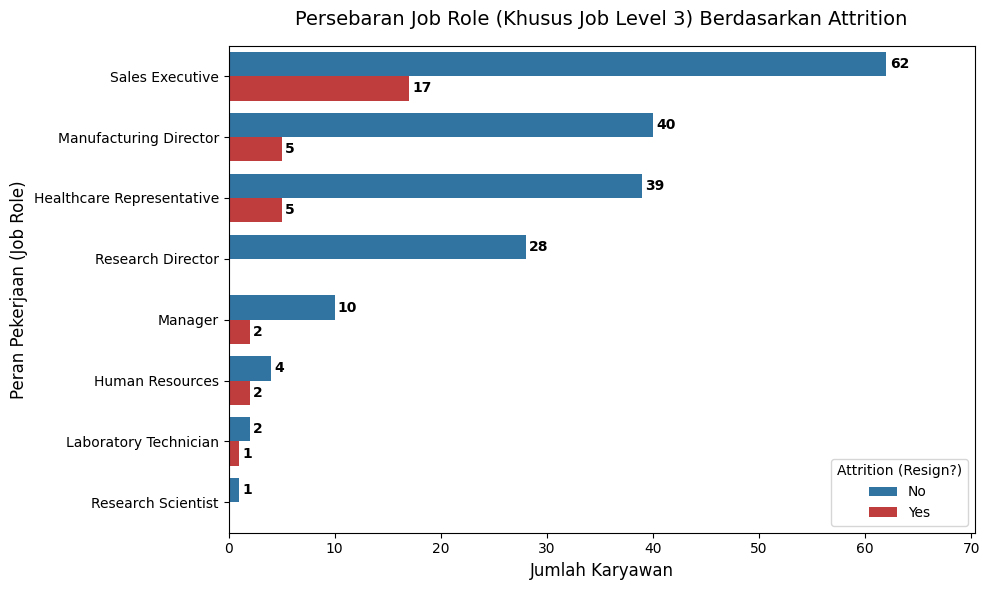

In [18]:
#Persebaran Job Role (Khusus Job Level 3) Berdasarkan Attrition
# 1. Filter data hanya untuk karyawan dengan JobLevel = 3
df_lvl3 = data[data['JobLevel'] == 3].copy()

# 2. Siapkan ukuran gambar
plt.figure(figsize=(10, 6))

# 3. Membuat Countplot Horizontal (Sumbu Y = JobRole)
# Kita tambahkan argumen 'order' agar jabatan diurutkan dari jumlah karyawan terbanyak
ax = sns.countplot(
    data=df_lvl3,
    y='JobRole', 
    hue='Attrition',
    palette={'No': '#1f77b4', 'Yes': '#d62728'},
    order=df_lvl3['JobRole'].value_counts().index 
)

# 4. Kustomisasi Judul dan Label
plt.title('Persebaran Job Role (Khusus Job Level 3) Berdasarkan Attrition', fontsize=14, pad=15)
plt.xlabel('Jumlah Karyawan', fontsize=12)
plt.ylabel('Peran Pekerjaan (Job Role)', fontsize=12)

# 5. Menambahkan label angka di ujung kanan setiap batang (bar)
for p in ax.patches:
    lebar = p.get_width() # Pada diagram horizontal, jumlah orang ditentukan dari lebarnya (width)
    
    # Cek untuk menghindari error jika ada kombinasi yang datanya kosong (NaN)
    if not math.isnan(lebar) and lebar > 0:
        ax.text(lebar + 0.3,                 # Geser angka sedikit ke kanan dari ujung bar
                p.get_y() + p.get_height()/2., # Posisi Y tepat di tengah bar
                f'{int(lebar)}', 
                ha='left', 
                va='center', 
                fontweight='bold')

# 6. Memperlebar sumbu X sedikit agar teks angka terluar tidak tertabrak garis batas kanvas
plt.xlim(0, ax.get_xlim()[1] * 1.08)

# 7. Memastikan posisi legend rapi
plt.legend(title='Attrition (Resign?)', loc='lower right')

plt.tight_layout()
plt.show()
